# 🤖 AgenticOps — Multi-Agent System with MCP Integration
---

## 👋 What Are We Building?

A **3-agent pipeline** where each agent has a specific role and communicates through **MCP tools**:

```
Your Task
  ↓
[PLANNER Agent]  → Calls MCP tool: plan_task()
  ↓         Breaks task into clear steps
[EXECUTOR Agent] → Calls MCP tool: execute_step()
  ↓         Runs each step and collects results
[REVIEWER Agent] → Calls MCP tool: review_output()
  ↓         Scores quality, spots redundancy & failures
 [END]
    ↓
[TRACE DISPLAY]  → Prints full agent interaction trace in Colab
    ↓
[IMPROVEMENT SUMMARY] → Structured report with metrics + fixes
```

Every agent interaction is **traced in Langfuse** so you can see exactly what each agent sent, received, and decided.

---

## 🧩 Key Concepts

| Concept | What it means here |
|---------|-------------------|
| **Agent** | An LLM that has a specific job (plan / execute / review) |
| **MCP Tool** | A callable function the agent uses to do its job |
| **FastMCP** | Python library to create MCP servers and clients |
| **LangGraph** | Connects the 3 agents into a workflow |
| **Langfuse** | Records every agent call so you can trace + debug |

---

## 🛠️ Stack
- **FastMCP** — MCP server + client (agent tool layer)
- **LangGraph** — multi-node agent orchestration
- **Azure OpenAI (GPT-4o)** — LLM powering all three agents
- **Langfuse v2** — full observability and tracing

---

## 📋 Required Outputs
| Output | Cell |
|--------|------|
| ✅ Multi-agent trace (in Colab) | Cell 10 |
| ✅ Multi-agent trace (in Langfuse) | Every run |
| ✅ Improvement summary | Cell 11 |

## 📦 Cell 1 — Install Dependencies

Run this first. **Restart the runtime** if Colab prompts you after installation.

## ⚙️ Cell 2 — Imports & Configuration

### Keys you need:
**Azure OpenAI** → `portal.azure.com` → your OpenAI resource → Keys and Endpoint

**Langfuse** → `cloud.langfuse.com` → Settings → API Keys → Create new key

In [19]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage
import os
load_dotenv()

True

## 🗂️ Cell 3 — Shared Agent State

All three agents share a single state dictionary.
Each agent reads what it needs and adds its output before passing the state forward.

In [21]:
from typing import TypedDict, Annotated, Sequence
from langchain_core.messages import BaseMessage

from typing import TypedDict, List, Dict, Any

class AgentState(TypedDict):
    query: str

    plan: Dict[str, Any]
    execution: Dict[str, Any]
    review: Dict[str, Any]

    trace: List[Dict[str, Any]]

## 🔧 Cell 4 — MCP Server (FastMCP)

`FastMCP` lets us define tools that agents call — just like a plugin system.
Each tool wraps an LLM call and returns a structured result.

| Tool | Called by | Does |
|------|----------|------|
| `plan_task` | Planner agent | Generates structured plan + step list |
| `execute_step` | Executor agent | Executes one step, returns result |
| `review_output` | Reviewer agent | Scores quality, finds issues |

In [14]:

from fastmcp import FastMCP
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field
from typing import List


  

llm = ChatOpenAI(temperature=0, model='gpt-5.4-nano')


mcp = FastMCP("Three Agent Pipeline")
print("MCP server object created ✅")

class PlanTaskResponse(BaseModel):
  """ Schema for output of plan task agent"""
  tasks_list: List[str] = Field(default_factory=list, description="List of tasks to be planned to complete the user query")


@mcp.tool
def plan_task(query:str) -> PlanTaskResponse:
  """The role of this agent is to break the given task into clear and precise steps. Each step should perform a single action and it should be definite. The steps should be clear, precise and unambiguous. 

  Args:
      text (str): The task the user wants to perform

  Returns:
      str: List of clear and definite steps to take to solve the given task
  """
  messages = [
    SystemMessage(content="""
      You are an expert planner. Following are the rules
      1. You must break the given task into definite precise and atomic steps. 
      2. Each step should perform single action and it should be clear, precise, complete and unambiguous. 
      3. Don't summarize the complete problem in the first line. 
      4. Every line should be an actionable item that the next agent can execute. 
      5. AVOID giving general instructions and give only actionable items. 
      6. Do NOT perform any actions, your task is only to list down the actionable items. This is MANDATORY
      7. Do NOT repeat steps, each step should be unique and complete.
      8. You MUST output a deterministic, non-redundant plan
      """),
    HumanMessage(content=f"Plan steps for the following task: {query}")
  ]
  

  structured_llm = llm.with_structured_output(PlanTaskResponse)
  result = structured_llm.invoke(messages)
  return result

class ExecuteTaskResponse(BaseModel):
  """ Schema for output of execute step agent"""
  execute_list: List[str] = Field(default_factory=list, description="List of tasks to be executed to complete the user query")

@mcp.tool
def execute_task(steps: PlanTaskResponse) -> ExecuteTaskResponse:
  """The role is to execute every step given in the steps list and return a list of output for each step
  """
  messages = [
    SystemMessage(content="""
      You are an Executor agent. You will receive a list of tasks that are planned by our planner agent. Following are the rules you MUST follow
      1. For EVERY item in the list, you MUST perform it and add it to a list
      2. You MUST return output for every step
      3. The length of array of input and output MUST be same. This is MANDATORY
      4. If the calculations require value of pi, ALWAYS use 3.142
      """),
    HumanMessage(content=f"Execute every action item in the given list: {steps}")
  ]
  

  structured_llm = llm.with_structured_output(ExecuteTaskResponse)
  result = structured_llm.invoke(messages)
  return result
  
class ReviewOutput(BaseModel):
  """ Schema for output of review output agent"""
  score_list: List[str] = Field(default_factory=list, description="Ranks each step for correctness, redundancy and quality")

@mcp.tool
def review_task(execution_steps: ExecuteTaskResponse) -> ReviewOutput:
  """The role is to score every execution step for correctness, redundancy and quality
  """
  messages = [
    SystemMessage(content="""
      You are an expert Ranking Agent. For every action item in the execution steps list, you must score it. The following are the guidelines for scoring.
      
      1. The score value should be between [-1, 1] with -1 implying  that step HIGHLY deviated from the original goal and 1 implying the step is HIGHLY aligned with the goal.
      2. If you spot any redundancy in the steps, then the score for the redundant steps must be reduced to account for redundancy penalty
      3. You MUST validate all calculations performed and should heavily penalize the score for wrong calculations.
      """),
    HumanMessage(content=f"For every step in this list, rank it between [-1, 1]: {execution_steps}")
  ]
  

  structured_llm = llm.with_structured_output(ReviewOutput)
  result = structured_llm.invoke(messages)
  return result
  
# output_1 = plan_task("The length of a rectangular box is 25cm and breadth is 60cm. The radius of a circle is 50cm. I want the sum of areas of both the figures")
# print(output_1)
# output_2 = execute_task(output_1)
# print(output_2)
# output_3 = review_task(output_2)
# print(output_3)


MCP server object created ✅


In [15]:
import threading
import time
def run_server():
    """Run FastMCP with SSE transport on port 8001 (blocking)."""
    mcp.run(transport="sse", host="127.0.0.1", port=8001)

# Daemon thread: terminates automatically when the notebook kernel stops
server_thread = threading.Thread(target=run_server, daemon=True)
server_thread.start()

# Give the server a moment to bind the port
time.sleep(2)
print("MCP server running at http://127.0.0.1:8001/mcp ✅")

╭──────────────────────────────────────────────────────────────────────────────╮                  
                 │                                                                              │                  
                 │                                                                              │                  
                 │                         ▄▀▀ ▄▀█ █▀▀ ▀█▀ █▀▄▀█ █▀▀ █▀█                        │                  
                 │                         █▀  █▀█ ▄▄█  █  █ ▀ █ █▄▄ █▀▀                        │                  
                 │                                                                              │                  
                 │                                                                              │                  
                 │                                                                              │                  
                 │                                FastMCP 3.4.2                                 │                  
                 │                            https://gofastmcp.com                             │                  
                 │                                                                              │                  
                 │                 🖥  Server:      Three Agent Pipeline, 3.4.2                  │                  
                 │                 🚀 Deploy free: https://horizon.prefect.io                   │                  
                 │                                                                              │                  
                 ╰──────────────────────────────────────────────────────────────────────────────╯

[06/25/26 01:04:42] INFO     Starting MCP server 'Three Agent   ]8;id=2758095;file:///Users/omkardalvi/github-repos/langgraph-mcp-server-workflow/.venv/lib/python3.12/site-packages/fastmcp/server/mixins/transport.py\transport.py]8;;\:]8;id=2758096;file:///Users/omkardalvi/github-repos/langgraph-mcp-server-workflow/.venv/lib/python3.12/site-packages/fastmcp/server/mixins/transport.py#304\304]8;;\
                             Pipeline' with transport 'sse' on                  
                             http://127.0.0.1:8001/sse                          
INFO:     Started server process [8060]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://127.0.0.1:8001 (Press CTRL+C to quit)


MCP server running at http://127.0.0.1:8001/mcp ✅


INFO:     127.0.0.1:62515 - "GET /mcp HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:62515 - "GET /favicon.ico HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:62522 - "GET / HTTP/1.1" 404 Not Found
INFO:     127.0.0.1:62526 - "GET /sse HTTP/1.1" 200 OK


## 🔌 Cell 5 — MCP Client Helper & JSON Parser

Two utility functions used by every agent node.

In [27]:
import json

from fastmcp import Client
from fastmcp.client.transports import SSETransport

client = Client(
    SSETransport("http://127.0.0.1:8001/sse")
)


async def call_mcp_tool(tool_name: str, arguments: dict):
    async with client:
        result = await client.call_tool(
            tool_name,
            arguments
        )

    return result.data


def parse_result(result):
    if hasattr(result, "model_dump"):
        return result.model_dump()

    return result

## 📡 Cell 6 — Langfuse Tracer

Tracks every agent interaction with full prompt + response content.

| Method | Shows in Langfuse |
|--------|------------------|
| `agent_span()` | Agent execution timeline block |
| `mcp_call()` | Full MCP tool input + output |
| `score()` | Quality score in Scores tab |
| `done()` | Trace summary + dashboard link |

In [ ]:
from langfuse import Langfuse

langfuse = Langfuse()

trace = langfuse.trace(
    name="multi-agent-pipeline"
)

In [28]:
from langfuse import Langfuse

langfuse = Langfuse()


def log_agent(trace, agent_name, tool_name, input_data, output_data):

    trace.append({
        "agent": agent_name,
        "tool": tool_name,
        "input": input_data,
        "output": output_data
    })

    return trace

## 🤖 Cell 7 — The Three Agent Nodes

Each agent:
1. Reads from state
2. Calls its MCP tool via `call_mcp_tool()`
3. Parses the result
4. Logs to Langfuse
5. Returns updated state

In [29]:
async def planner_node(state: AgentState):

    result = await call_mcp_tool(
        "plan_task",
        {"query": state["query"]}
    )

    result = parse_result(result)

    trace = log_agent(
        state.get("trace", []),
        "planner",
        "plan_task",
        state["query"],
        result
    )

    return {
        "plan": result,
        "trace": trace
    }

In [30]:
async def executor_node(state: AgentState):

    result = await call_mcp_tool(
        "execute_task",
        {"steps": state["plan"]}
    )

    result = parse_result(result)

    trace = log_agent(
        state["trace"],
        "executor",
        "execute_task",
        state["plan"],
        result
    )

    return {
        "execution": result,
        "trace": trace
    }

In [31]:
async def reviewer_node(state: AgentState):

    result = await call_mcp_tool(
        "review_task",
        {"execution_steps": state["execution"]}
    )

    result = parse_result(result)

    trace = log_agent(
        state["trace"],
        "reviewer",
        "review_task",
        state["execution"],
        result
    )

    return {
        "review": result,
        "trace": trace
    }

## 🔀 Cell 8 — LangGraph Assembly

Linear pipeline — no loops, no conditional routing:
```
planner → executor → reviewer → END
```

In [32]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(AgentState)

builder.add_node("planner", planner_node)
builder.add_node("executor", executor_node)
builder.add_node("reviewer", reviewer_node)

builder.add_edge(START, "planner")
builder.add_edge("planner", "executor")
builder.add_edge("executor", "reviewer")
builder.add_edge("reviewer", END)

graph = builder.compile()

## ▶️ Cell 9 — Run the Multi-Agent Pipeline

Runs all 3 test cases. After completion:
- **Cell 10** displays the full multi-agent trace in Colab
- **Cell 11** displays the improvement summary report
- Full traces are also in Langfuse

In [33]:
user_query = 'The length of a rectangular box is 25cm and breadth is 60cm. The radius of a circle is 50cm. I want the sum of areas of both the figures'
result = await graph.ainvoke({
    "query": user_query,
    "trace": []
})


INFO:     127.0.0.1:62891 - "GET /sse HTTP/1.1" 200 OK
INFO:     127.0.0.1:62892 - "POST /messages/?session_id=db421bd160a046a1be77254ab4a230fe HTTP/1.1" 202 Accepted
INFO:     127.0.0.1:62892 - "POST /messages/?session_id=db421bd160a046a1be77254ab4a230fe HTTP/1.1" 202 Accepted
INFO:     127.0.0.1:62892 - "POST /messages/?session_id=db421bd160a046a1be77254ab4a230fe HTTP/1.1" 202 Accepted
INFO:     127.0.0.1:62892 - "POST /messages/?session_id=db421bd160a046a1be77254ab4a230fe HTTP/1.1" 202 Accepted
INFO:     127.0.0.1:62896 - "GET /sse HTTP/1.1" 200 OK
INFO:     127.0.0.1:62897 - "POST /messages/?session_id=05ec0d3946c2471bbfafc6548dcf157c HTTP/1.1" 202 Accepted
INFO:     127.0.0.1:62897 - "POST /messages/?session_id=05ec0d3946c2471bbfafc6548dcf157c HTTP/1.1" 202 Accepted
INFO:     127.0.0.1:62897 - "POST /messages/?session_id=05ec0d3946c2471bbfafc6548dcf157c HTTP/1.1" 202 Accepted
INFO:     127.0.0.1:62897 - "POST /messages/?session_id=05ec0d3946c2471bbfafc6548dcf157c HTTP/1.1" 202 Acc

In [34]:
print(result)

{'query': 'The length of a rectangular box is 25cm and breadth is 60cm. The radius of a circle is 50cm. I want the sum of areas of both the figures', 'plan': Root(tasks_list=['Interpret the rectangular box dimensions as length = 25 cm and breadth = 60 cm and identify the rectangle area formula to use.', 'Compute the rectangle area as 25 * 60 and record the result in square centimeters.', 'Interpret the second figure as a circle with radius r = 50 cm and identify the circle area formula to use.', 'Compute the circle area as π * (50^2) and record the result in square centimeters (keep π symbolic).', 'Add the rectangle area and the circle area to obtain the required sum of areas.', 'If a numerical value is required, substitute π = 3.14159 (or specified value) and compute the final sum in square centimeters.', 'State the final sum of areas with correct units (cm²) and with appropriate rounding if numerical substitution was performed.']), 'execution': Root(execute_list=['Interpreted rectang

## 🔁 Cell 10 — Multi-Agent Trace (Required Output 1)

Prints the full agent interaction trace for every run directly in Colab.
Shows exactly what each agent received, which tool it called, and what it produced.

In [35]:
print("=== MULTI AGENT TRACE ===\n")

for step in result["trace"]:

    print(f"Agent : {step['agent']}")
    print(f"Tool  : {step['tool']}")

    print("\nINPUT:")
    print(step["input"])

    print("\nOUTPUT:")
    print(step["output"])

    print("\n" + "="*60 + "\n")

=== MULTI AGENT TRACE ===

Agent : planner
Tool  : plan_task

INPUT:
The length of a rectangular box is 25cm and breadth is 60cm. The radius of a circle is 50cm. I want the sum of areas of both the figures

OUTPUT:
Root(tasks_list=['Interpret the rectangular box dimensions as length = 25 cm and breadth = 60 cm and identify the rectangle area formula to use.', 'Compute the rectangle area as 25 * 60 and record the result in square centimeters.', 'Interpret the second figure as a circle with radius r = 50 cm and identify the circle area formula to use.', 'Compute the circle area as π * (50^2) and record the result in square centimeters (keep π symbolic).', 'Add the rectangle area and the circle area to obtain the required sum of areas.', 'If a numerical value is required, substitute π = 3.14159 (or specified value) and compute the final sum in square centimeters.', 'State the final sum of areas with correct units (cm²) and with appropriate rounding if numerical substitution was performed.

## 📊 Cell 11 — Improvement Summary (Required Output 2)

Structured report across all runs covering:
- Coordination efficiency metrics
- Redundancy analysis
- Failure points
- Concrete optimisation recommendations

## 🔍 Cell 12 — Reading Multi-Agent Traces in Langfuse

---

### Step 1 — Find Your Traces
```
cloud.langfuse.com → your project → Tracing → Traces
→ filter by name: "multi-agent-pipeline"
```

### Step 2 — Trace Timeline
```
trace: multi-agent-pipeline
 ├── agent:planner       ← span: step_count, latency
 │   └── mcp:plan_task    ← generation: click → full plan JSON
 │
 ├── agent:executor       ← span: failures, redundancies count
 │   ├── mcp:execute_step   ← generation: Step 1 input → result
 │   ├── mcp:execute_step   ← generation: Step 2 input → result
 │   └── mcp:execute_step   ← generation: Step 3 input → result
 │
 └── agent:reviewer       ← span: final score
    └── mcp:review_output  ← generation: click → full review JSON
```

### Step 3 — What Each Click Shows
- **`mcp:plan_task`** → Left: task input | Right: full plan + steps JSON
- **`mcp:execute_step`** → Left: step + context | Right: result + status
- **`mcp:review_output`** → Left: all results | Right: score + feedback JSON

### Step 4 — Scores Tab
`Trace detail → Scores → "agent-quality"` shows quality score per run

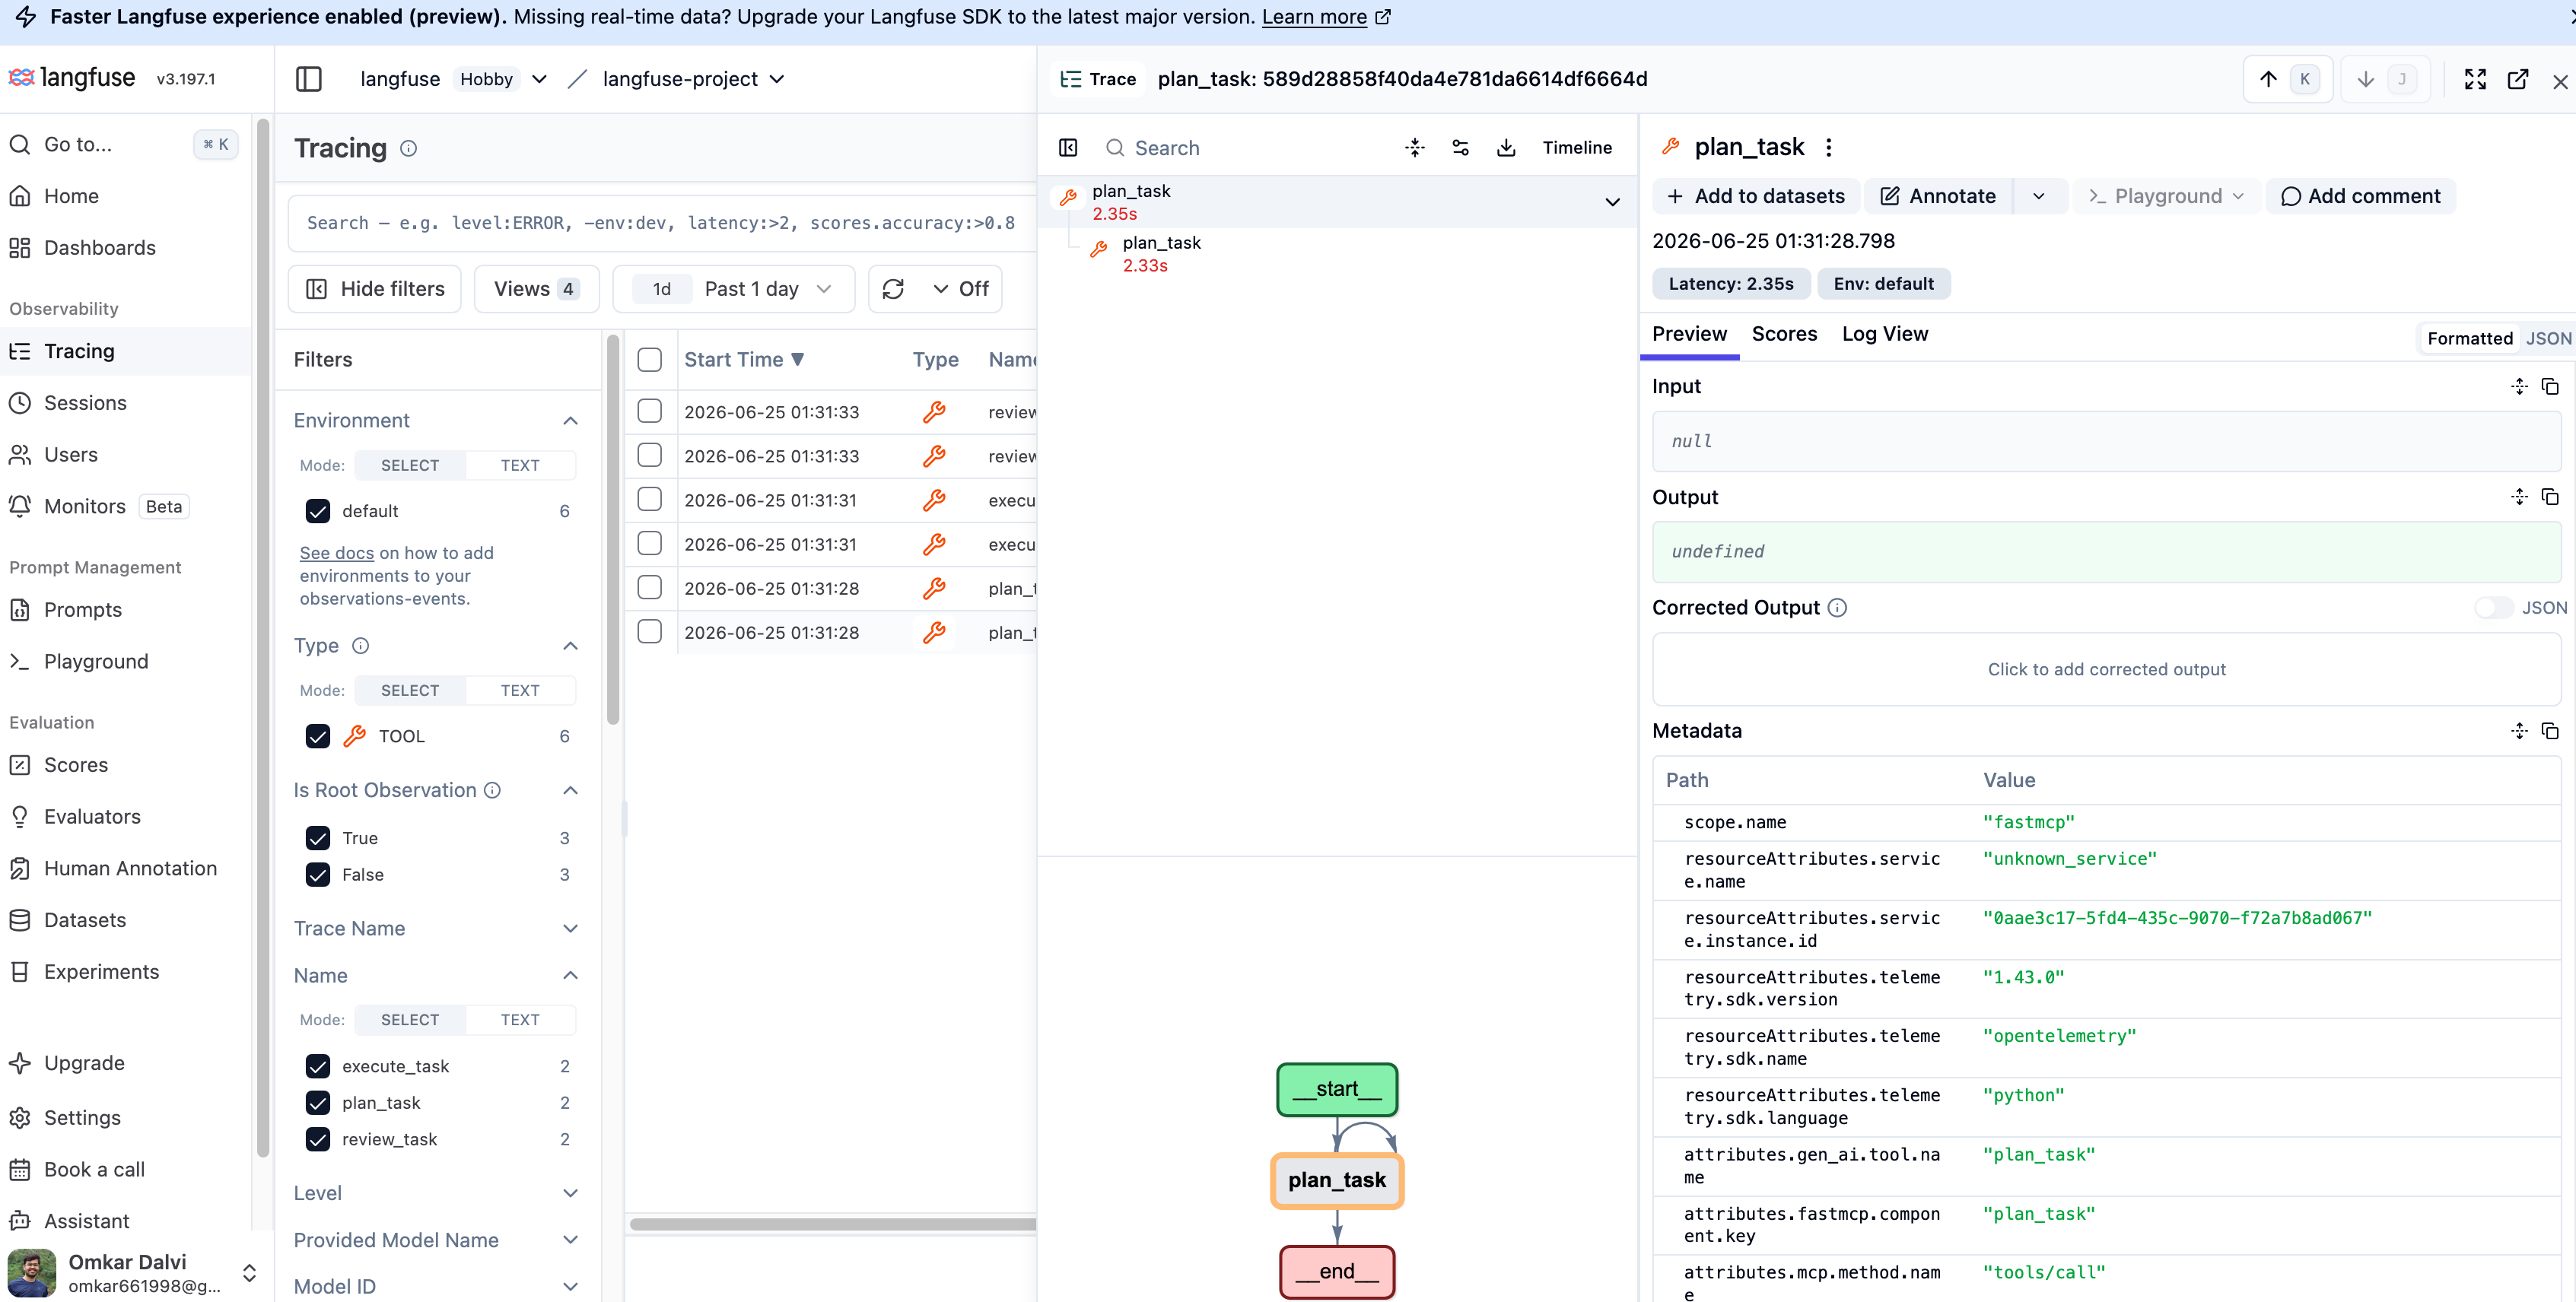

In [40]:
from IPython.display import Image

# For a local file in the same directory
Image("img/langfuse_tracing_1.png")

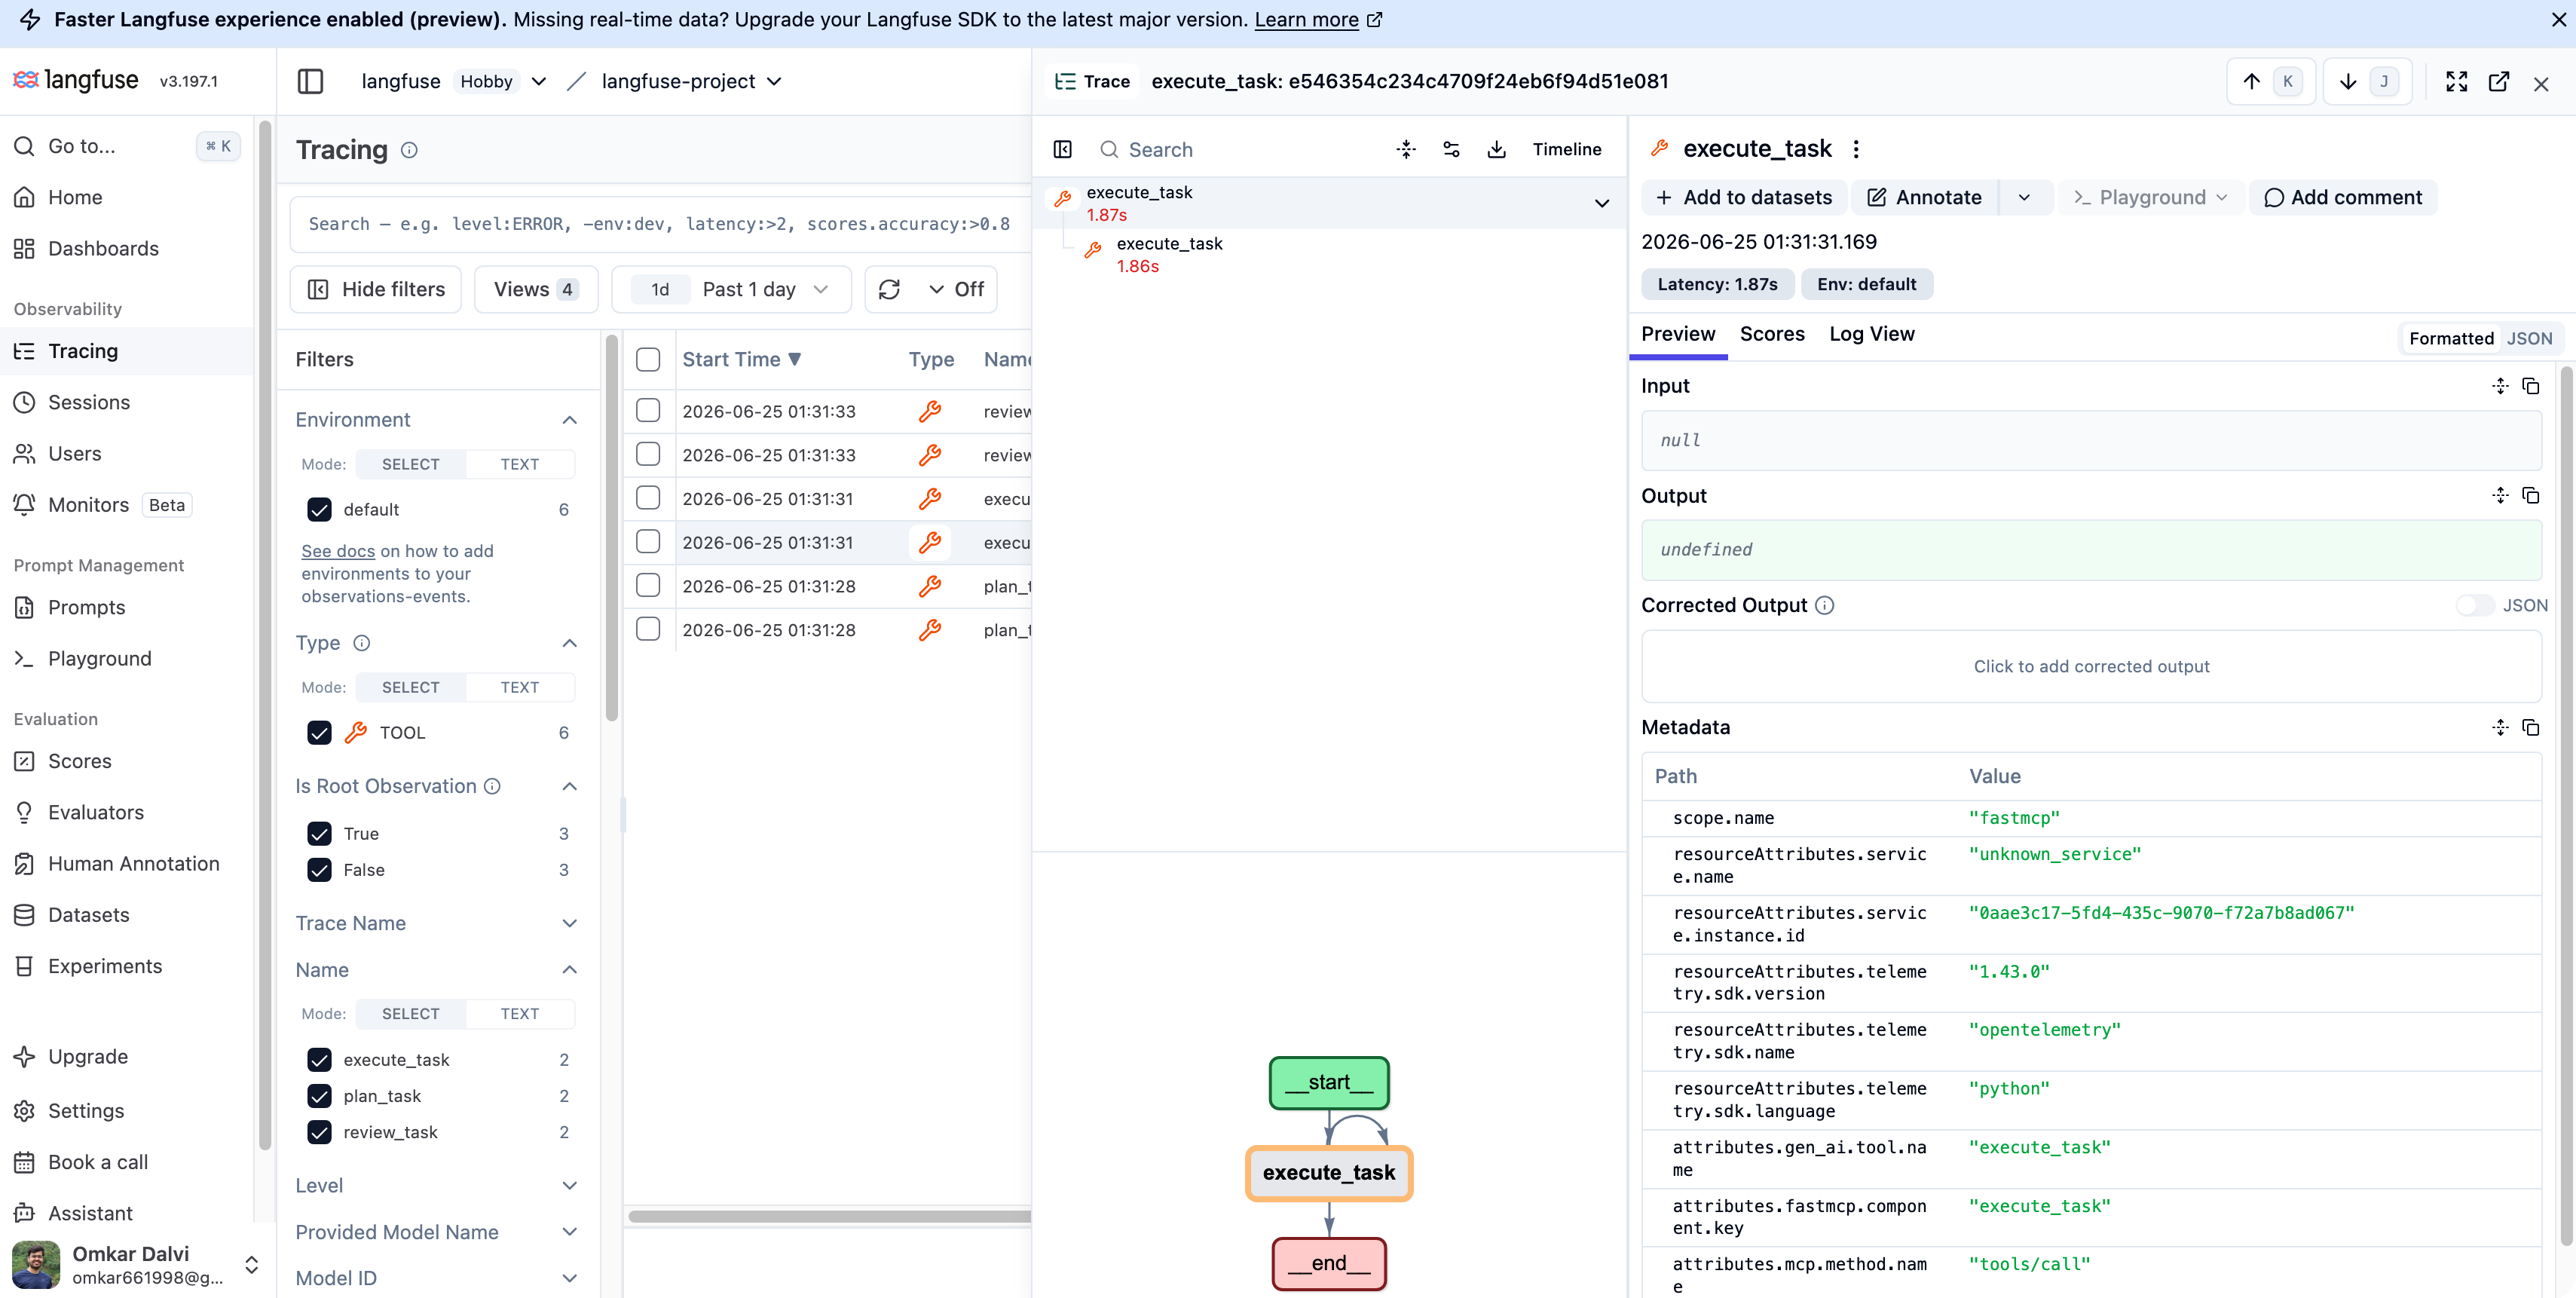

In [41]:
from IPython.display import Image

# For a local file in the same directory
Image("img/langfuse_tracing_2.png")

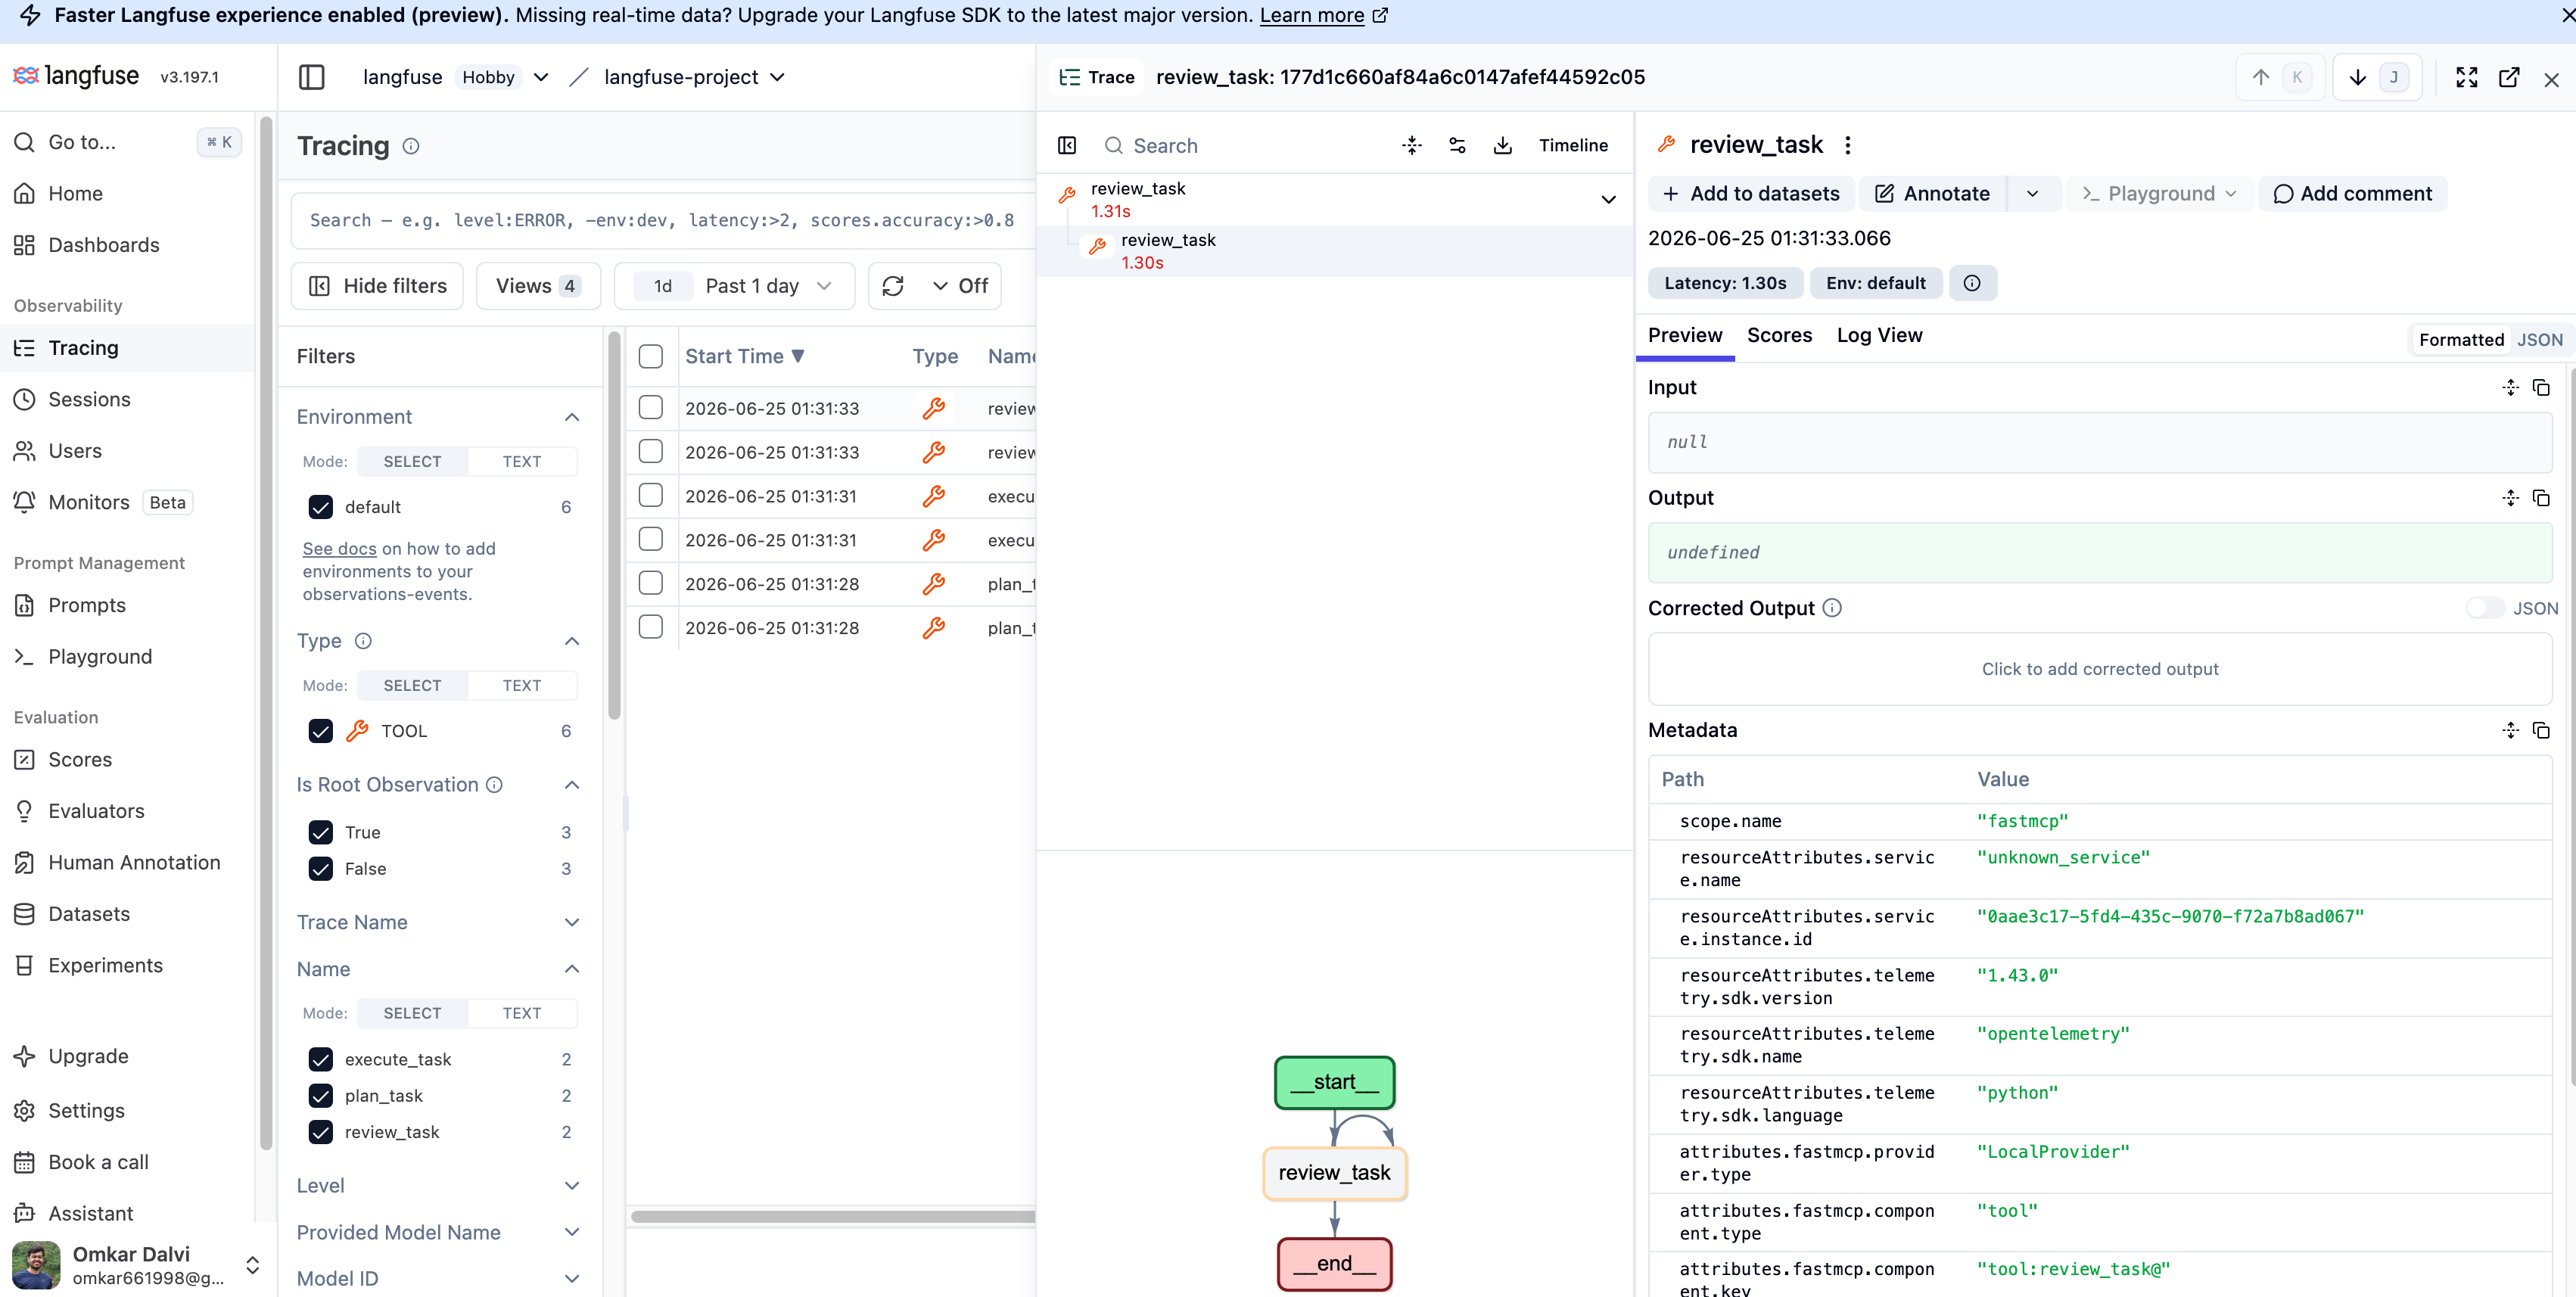

In [42]:
from IPython.display import Image

# For a local file in the same directory
Image("img/langfuse_tracing_3.png")